# Phần 1: Khảo Sát Dữ Liệu (Exploratory Data Analysis — EDA)
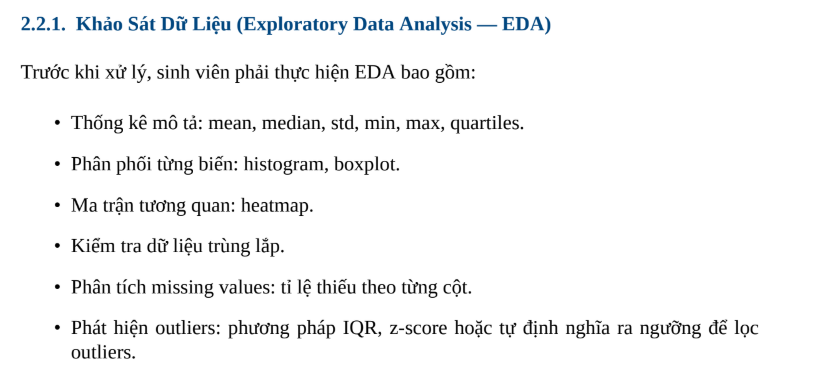

## 1. Kiểm tra chất lượng dữ liệu cơ bản

### 1.1. Thống kê mô tả

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style cho đồ thị
sns.set_theme(style="whitegrid")

# Load dữ liệu
df = pd.read_csv('data/AmesHousing.csv')

# Loại bỏ khoảng trắng thừa trong tên cột
df.columns = df.columns.str.strip()

print(f"Kích thước bộ dữ liệu: {df.shape}")

# Thống kê mô tả (mean, median, std, min, max, quartiles)
display(df.describe())

# Xem qua các biến phân loại
display(df.describe(exclude='number'))

Kích thước bộ dữ liệu: (2930, 82)


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


### 1.2. Kiểm tra dữ liệu trùng lắp

In [2]:
num_duplicates = df.duplicated().sum()
print(f"Số lượng dòng dữ liệu bị trùng lắp (Duplicates): {num_duplicates}")

Số lượng dòng dữ liệu bị trùng lắp (Duplicates): 0


#### Nhận xét: Kiểm tra dữ liệu trùng lắp
Qua hàm `duplicated()`, ta thấy bộ dữ liệu Ames Housing không có dòng dữ liệu nào bị trùng lắp hoàn toàn (0 duplicates). Điều này chứng tỏ khâu thu thập dữ liệu gốc đã được quản lý định danh (thông qua mã PID của từng căn nhà) rất tốt. Do đó, nhóm không cần thực hiện bước xóa dòng trùng (drop duplicates) trong quá trình tiền xử lý.

## 2. Trực quan hóa dữ liệu (Histogram & Boxplot)

### 2.1. Khảo sát Biến mục tiêu (SalePrice)

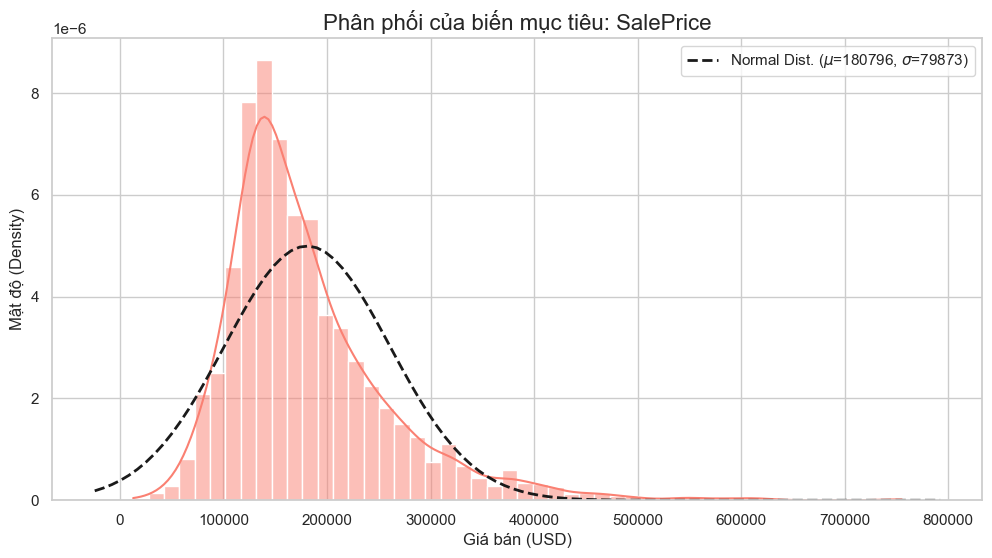

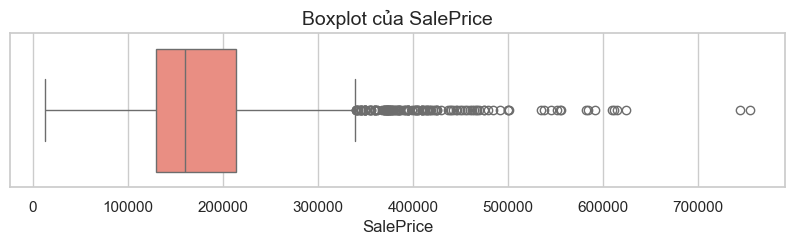

In [3]:
from scipy.stats import norm

# Thiết kế biểu đồ phân tích cho biến mục tiêu
plt.figure(figsize=(12, 6))

# Vẽ Histogram kết hợp đường KDE
sns.histplot(df['SalePrice'], kde=True, stat="density", color="salmon", bins=50)

# Chèn thêm đường cong phân phối chuẩn (Normal Distribution) để so sánh độ lệch
mu, std = norm.fit(df['SalePrice'].dropna())
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, linestyle='--', label=rf'Normal Dist. ($\mu$={mu:.0f}, $\sigma$={std:.0f})')

plt.title('Phân phối của biến mục tiêu: SalePrice', fontsize=16)
plt.xlabel('Giá bán (USD)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.legend()
plt.show()

# Vẽ Boxplot cho SalePrice để soi outliers của y
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['SalePrice'], color='salmon')
plt.title('Boxplot của SalePrice', fontsize=14)
plt.show()

#### Nhận xét về Biến mục tiêu (Target Variable Analysis)
* **Phân phối:** Biểu đồ Histogram cho thấy `SalePrice` bị lệch phải (Right-skewed) rõ rệt. Đỉnh của phân phối tập trung ở khoảng 130,000 - 160,000 USD, nhưng có một dải đuôi dài kéo về phía các mức giá cao (trên 500,000 USD).
* **So sánh với Phân phối chuẩn:** Đường cong thực tế (Salmon) lệch đáng kể so với đường lý thuyết (Black dashed), cho thấy dữ liệu không tuân theo phân phối chuẩn.
* **Outliers:** Boxplot xác nhận sự tồn tại của nhiều giá trị ngoại lệ ở phía cận trên (giá cao).
* **Kết luận cho OLS:** Để thỏa mãn giả định về phân phối chuẩn của phần dư trong mô hình OLS, việc áp dụng phép biến đổi **Log-transformation** cho `SalePrice` là bắt buộc trước khi đưa vào huấn luyện.

### 2.2. Khảo sát Biến dự báo (Predictors)

12 biến được chọn để vẽ phân phối: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Full Bath', 'Mas Vnr Area', 'TotRms AbvGrd', 'Fireplaces', 'BsmtFin SF 1', 'Lot Frontage']


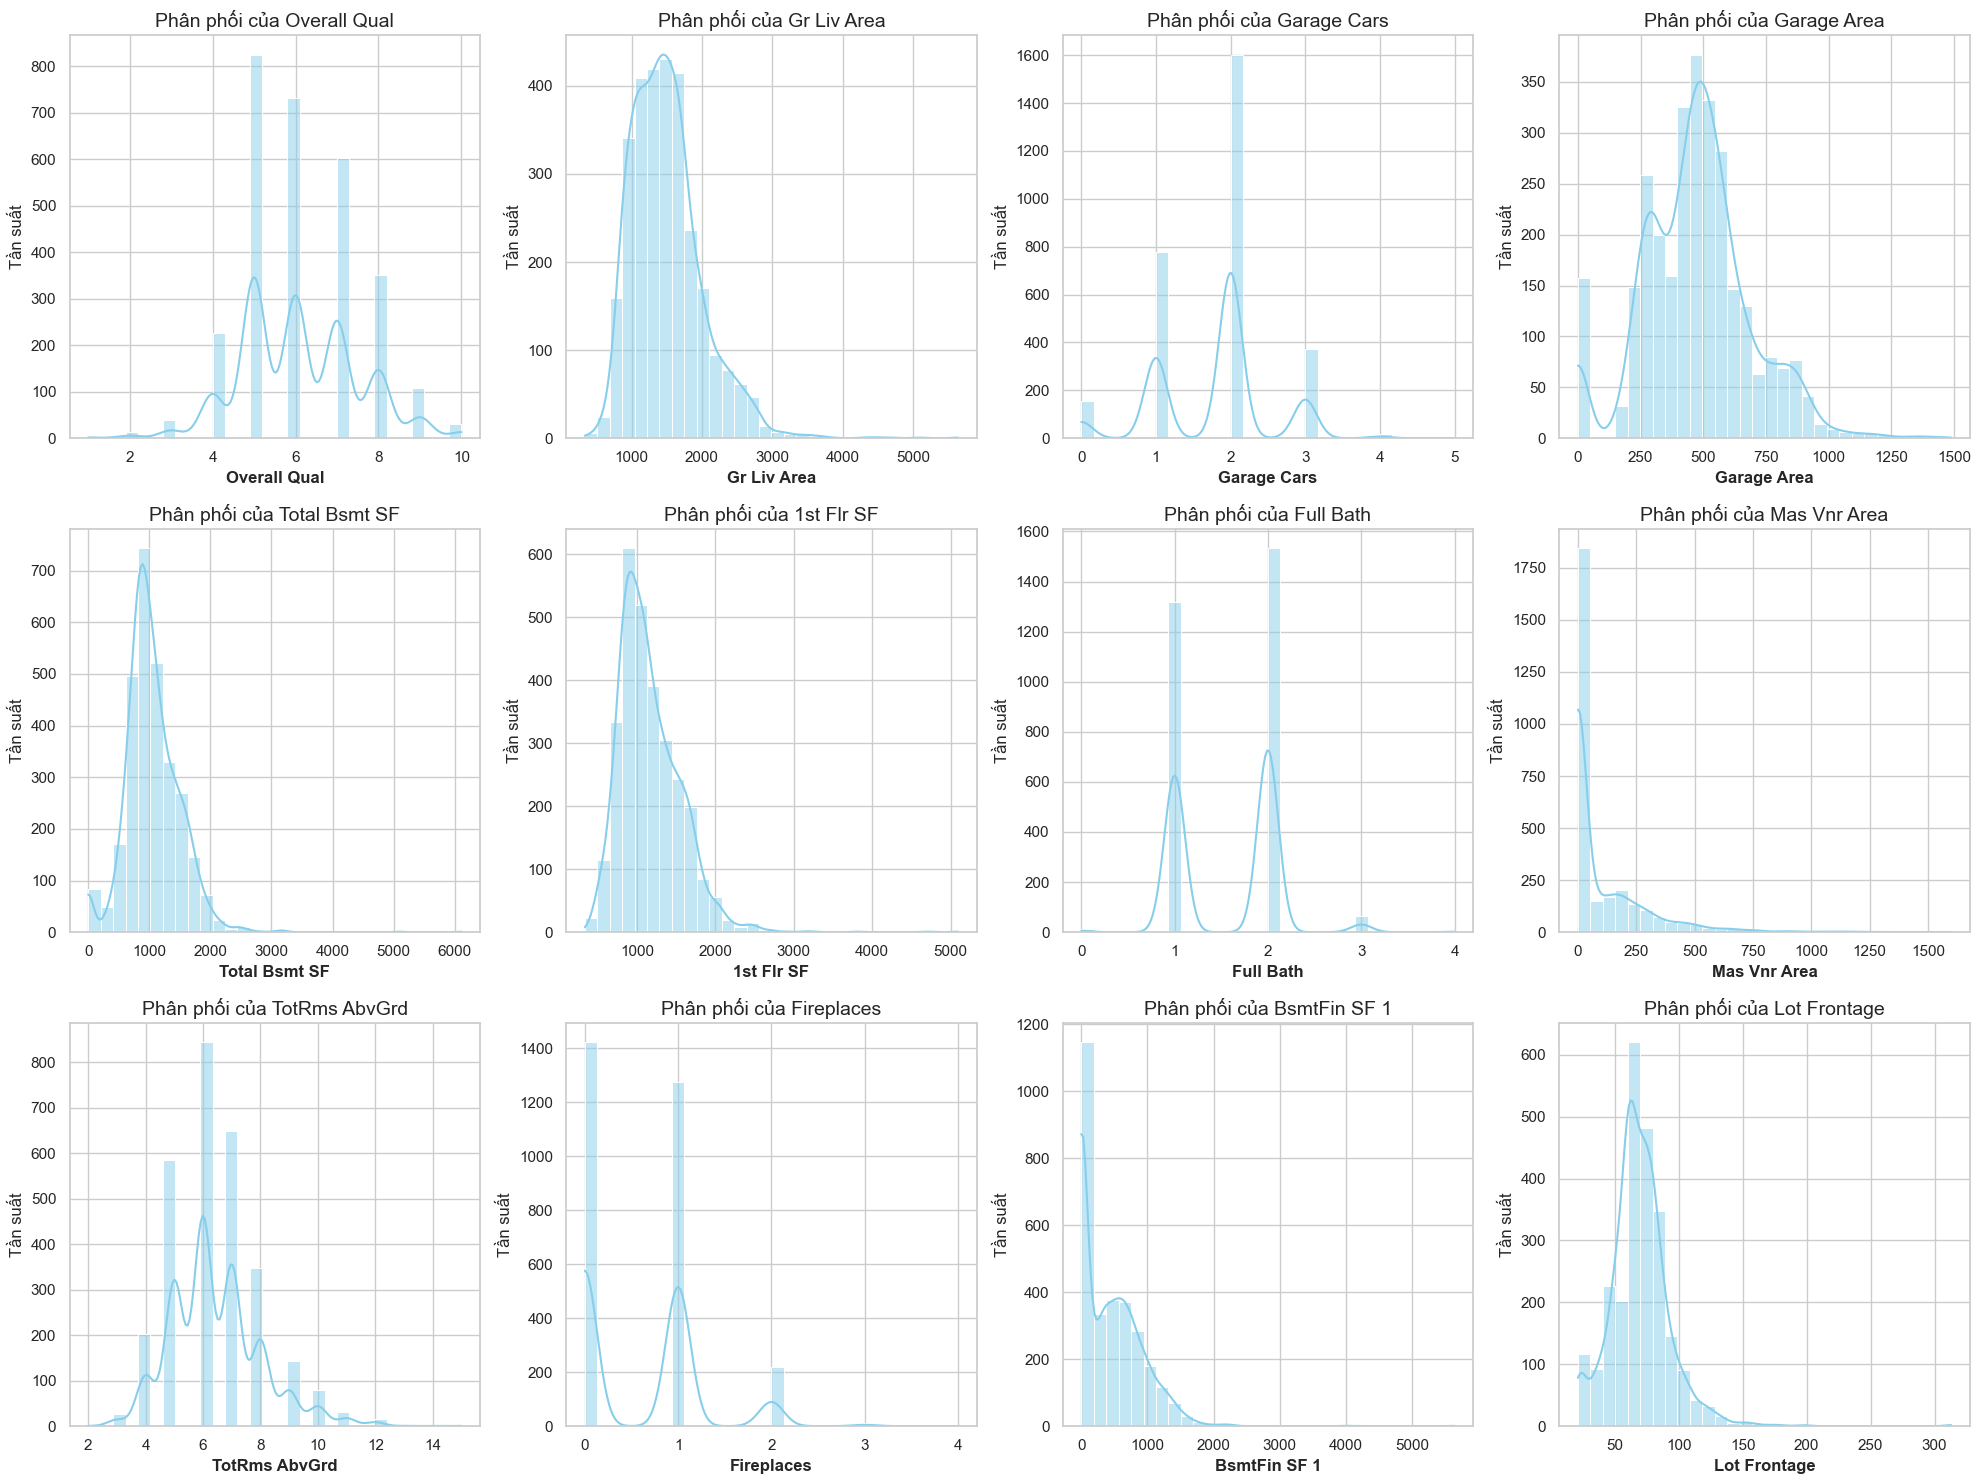

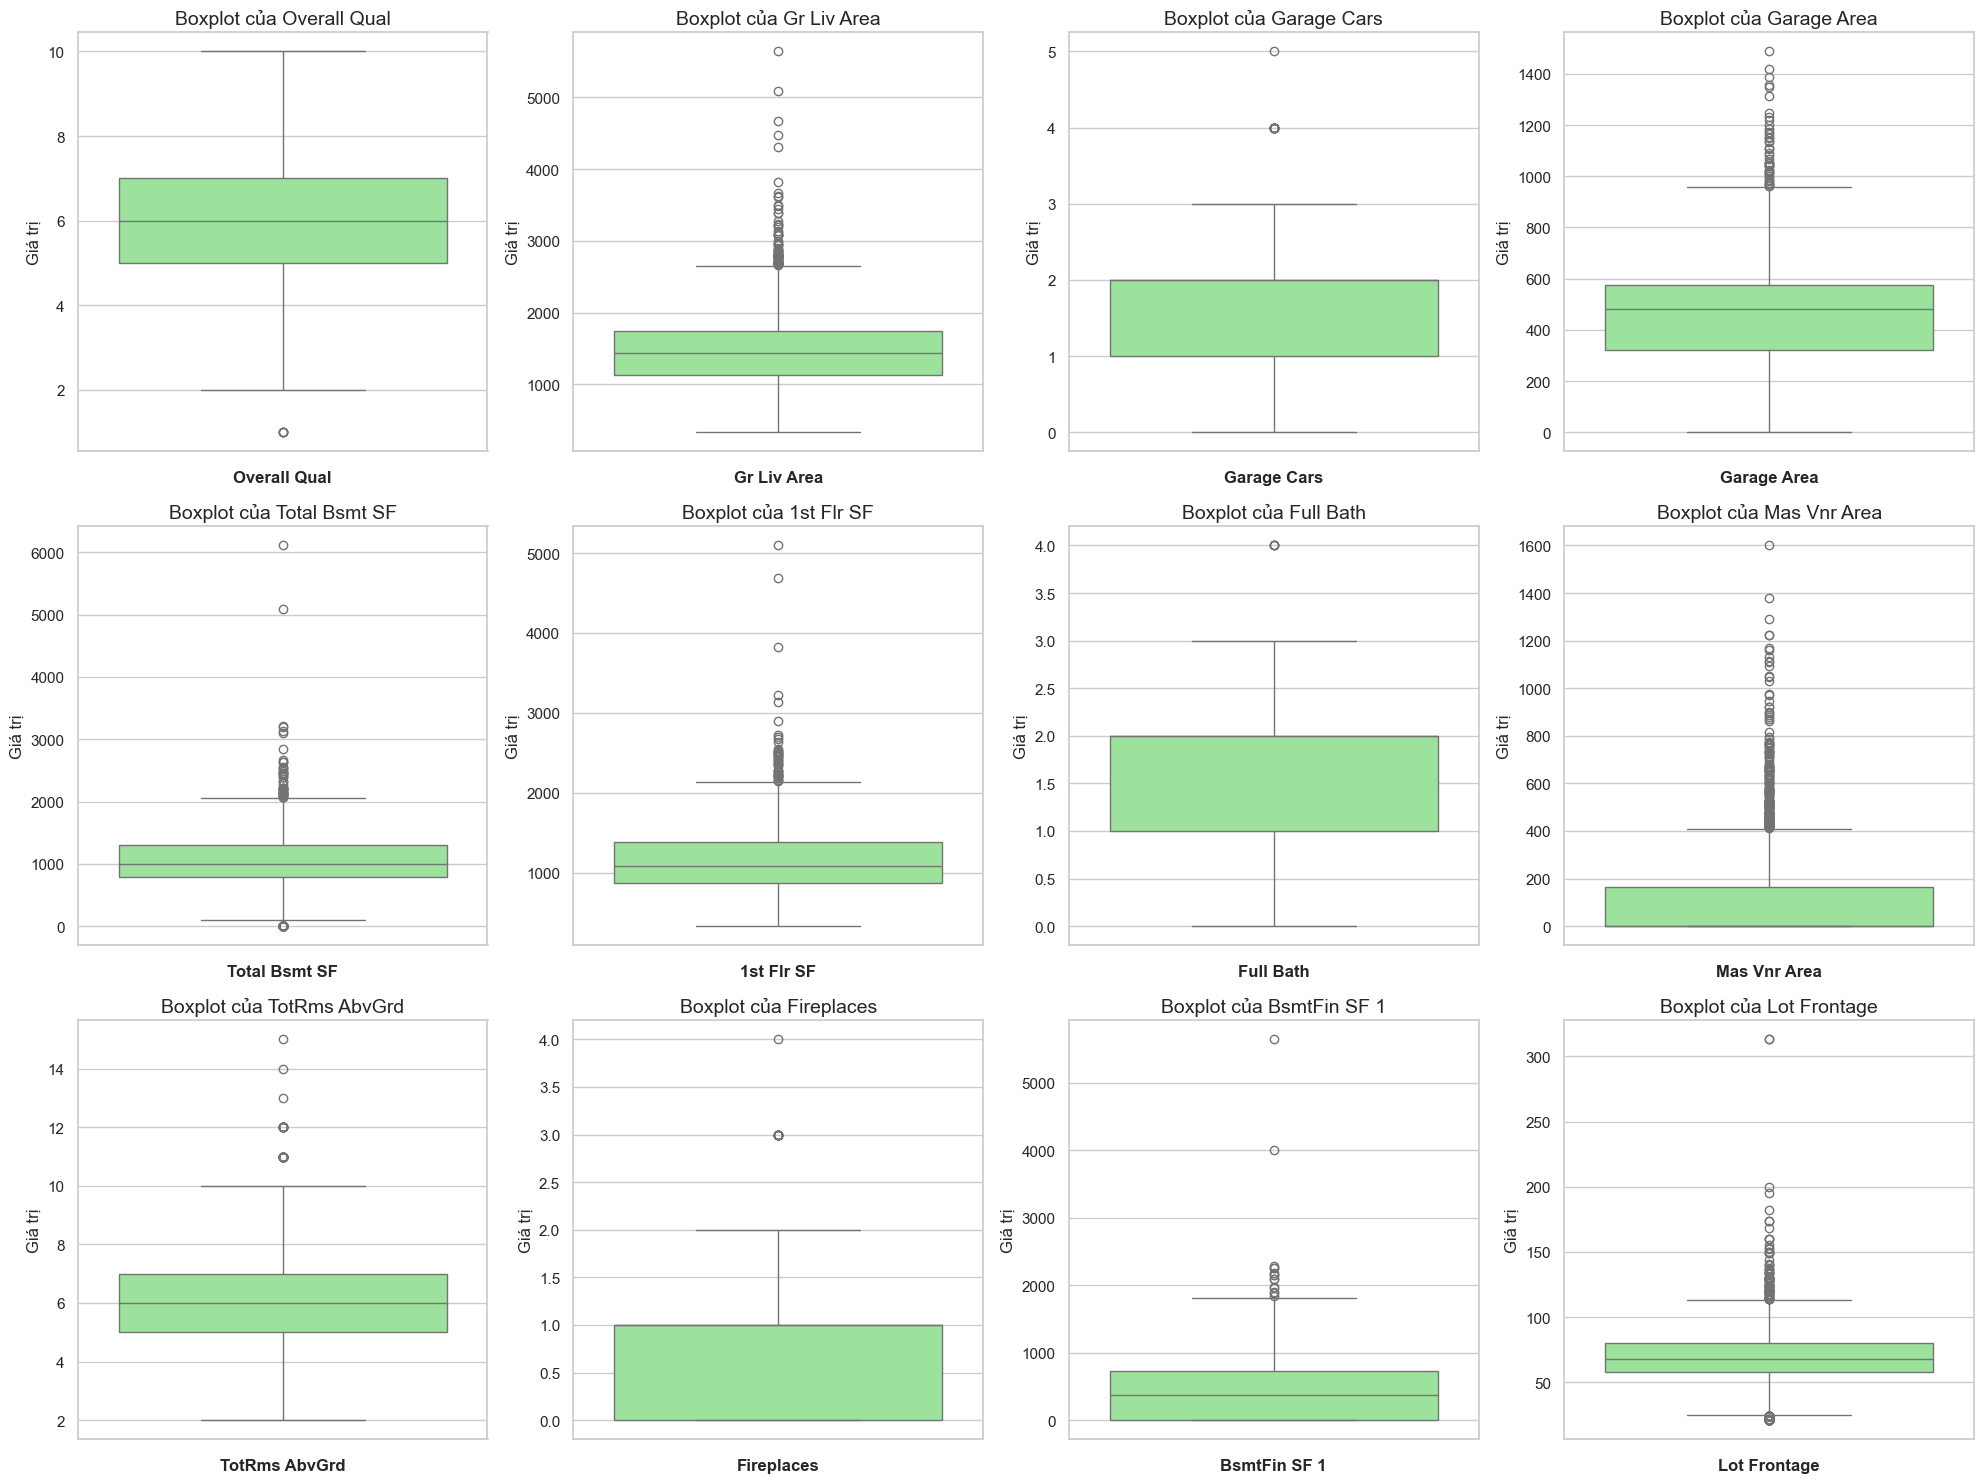

In [4]:
# Tìm các biến có tương quan cao nhất với SalePrice để ưu tiên khảo sát
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Lấy top 30 biến tương quan mạnh nhất với SalePrice
top_30_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(30).index

# Định nghĩa danh sách các biến mang tính chất thời gian (năm/tháng)
temporal_cols = ['Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Yr Sold', 'Mo Sold']

# Lọc ra top các biến tương quan cao, bỏ qua biến mục tiêu (index 0)
# và bỏ qua các biến nằm trong danh sách temporal_cols
predictors_to_plot = [col for col in top_30_features[1:] if col not in temporal_cols][:12]

print(f"12 biến được chọn để vẽ phân phối: {predictors_to_plot}")

# Vẽ lưới Histogram 3x4
plt.figure(figsize=(20, 15))
for i, col in enumerate(predictors_to_plot, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Phân phối của {col}', fontsize=14)
    plt.xlabel(col, fontsize=12, fontweight='bold')
    plt.ylabel('Tần suất', fontsize=12)
plt.tight_layout()
plt.show()

# Vẽ lưới Boxplot 3x4
plt.figure(figsize=(20, 15))
for i, col in enumerate(predictors_to_plot, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot của {col}', fontsize=14)
    plt.ylabel('Giá trị', fontsize=12)
    plt.xlabel(col, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### Nhận xét về Phân phối của các Biến dự báo
Qua quan sát biểu đồ Histogram của 12 biến độc lập quan trọng nhất, ta rút ra các đặc điểm sau:

* **Các biến đo lường diện tích (`Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`):** Hầu hết đều có xu hướng lệch phải (Right-skewed). Điều này phản ánh thực tế cấu trúc nhà ở: đại đa số là nhà có diện tích trung bình, chỉ một thiểu số ít là các dinh thự hoặc nhà có diện tích cực lớn.
* **Các biến đánh giá chất lượng (`Overall Qual`, `Garage Cars`, `Full Bath`):** Có dạng phân phối đa đỉnh (Multimodal) hoặc phân bố theo cụm rời rạc. Đây là đặc trưng hiển nhiên của các biến mang tính chất thứ bậc (Ordinal) hoặc số đếm (Count).
* **Đề xuất xử lý:** Sự lệch phải của các biến diện tích có thể làm tăng phương sai của phần dư trong mô hình OLS. Nhóm sẽ cân nhắc áp dụng phép biến đổi Logarit (Log-transform) cho các biến số học liên tục bị lệch nặng để đưa chúng về dạng chuẩn hơn trong bước Pipeline.

#### Nhận xét về Giá trị ngoại lệ (Visual Outliers) của các Biến dự báo
Qua quan sát hình dáng biểu đồ Boxplot, ta nhận thấy sự xuất hiện của rất nhiều điểm ngoại lệ (các chấm đen nằm ngoài râu của đồ thị):

* **Các điểm đòn bẩy tiềm năng (Potential Leverage Points):** Dễ thấy nhất ở biến `Gr Liv Area` và `Total Bsmt SF`. Có những quan sát nằm tách biệt hoàn toàn ở phía trên đỉnh đồ thị (đại diện cho các căn nhà có diện tích cực lớn). Trong lý thuyết OLS, đây là những điểm có nguy cơ trở thành "đòn bẩy", kéo lệch đường hồi quy của toàn bộ tập dữ liệu.
* **Các biến tiện ích đặc thù:** Những biến như `Mas Vnr Area` (Diện tích ốp gạch/đá) hay `Wood Deck SF` (Diện tích sàn gỗ) có mật độ điểm ngoại lệ rất dày đặc. Lý do trực quan là phần lớn các căn nhà không có tiện ích này (giá trị = 0), khiến phần thân hộp (hộp chứa 50% dữ liệu) bị bóp nghẹt lại, đẩy các giá trị > 0 ra ngoài khoảng râu đồ thị.
* **Định hướng bước tiếp theo:** Từ những quan sát trực quan này, nhóm sẽ tiến hành định lượng cụ thể số lượng ngoại lệ bằng công thức thống kê ở phần "Phân tích chuyên sâu" bên dưới để có cơ sở đưa ra thuật toán xử lý (Winsorization) trong `DataPipeline`.

### 2.3. Đánh giá mức độ tương quan (Heatmap)

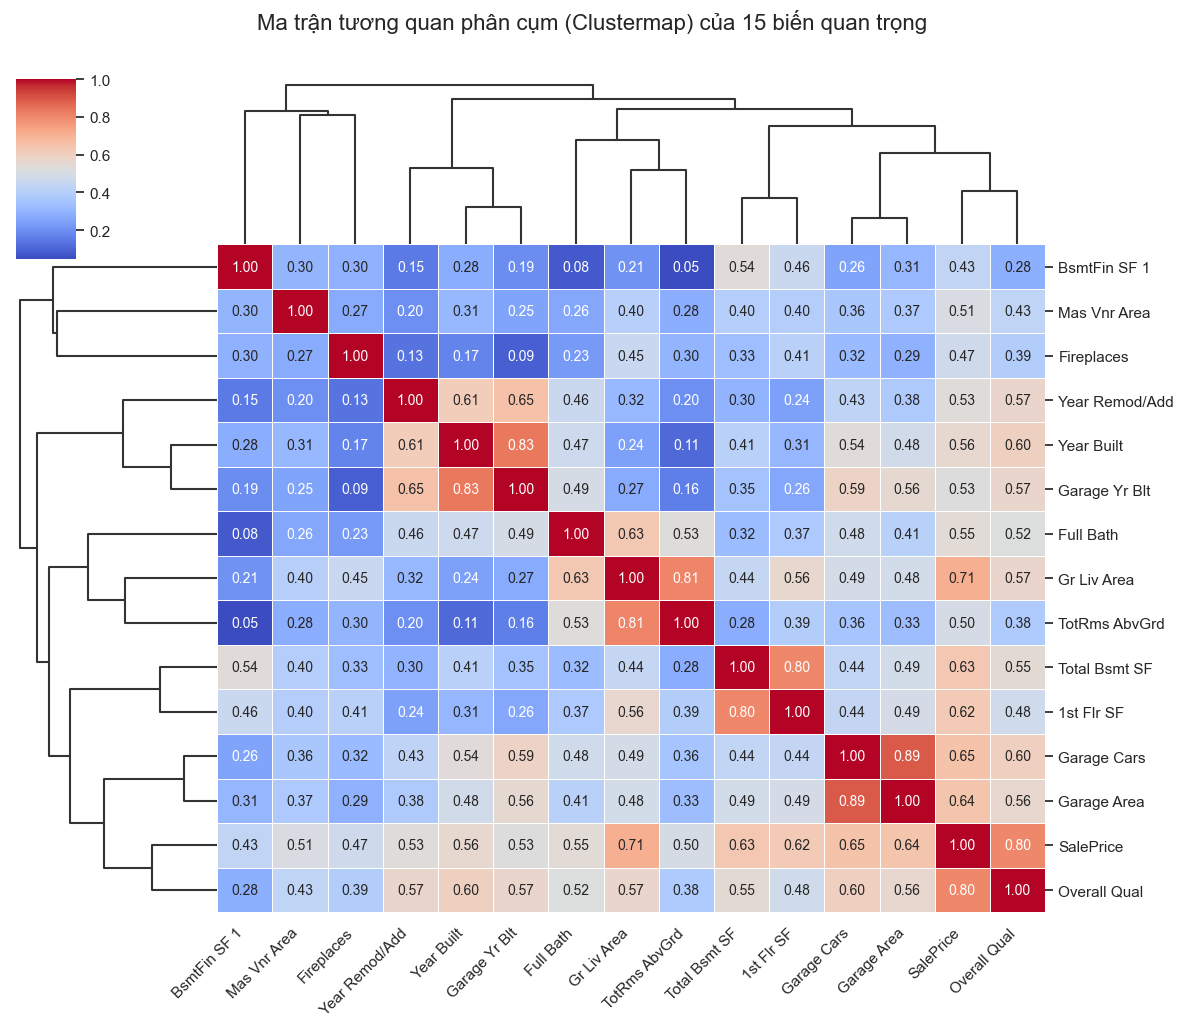

In [5]:
# Lấy top 15 biến có độ tương quan cao nhất với SalePrice
top_15_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(15).index
top_15_corr = df[top_15_features].corr()

# Vẽ Clustermap để thuật toán tự động gom các biến đa cộng tuyến lại gần nhau
cluster = sns.clustermap(top_15_corr,
                         annot=True,
                         fmt=".2f",
                         cmap='coolwarm',
                         linewidths=0.5,
                         figsize=(12, 10), # Clustermap dùng figsize bên trong hàm
                         annot_kws={"size": 10},
                         tree_kws={"linewidths": 1.5}) # Làm nét đường cây phân cụm

cluster.fig.suptitle('Ma trận tương quan phân cụm (Clustermap) của 15 biến quan trọng', fontsize=16, y=1.05)

plt.setp(cluster.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.setp(cluster.ax_heatmap.get_yticklabels(), rotation=0)

plt.show()

#### Nhận xét về Ma trận tương quan phân cụm (Clustermap)
Thay vì sắp xếp thủ công, nhóm sử dụng thuật toán Phân cụm phân cấp (Hierarchical Clustering) thông qua biểu đồ Clustermap để máy tính **tự động** tính toán khoảng cách và gom nhóm các biến có độ tương quan cao lại với nhau. Qua quan sát, ta rút ra các kết luận quan trọng:

* **Các biến dự báo "át chủ bài":** `Overall Qual` (Chất lượng tổng thể) và `Gr Liv Area` (Diện tích sinh hoạt) đã khẳng định vị thế là 2 biến độc lập có tác động mạnh mẽ nhất đến `SalePrice`. Đây sẽ là các biến mang trọng số cao trong phương trình hồi quy.
* **Phát hiện Đa cộng tuyến (Multicollinearity) tự động:** Nhờ cây phân cụm (dendrogram), thuật toán đã nhóm thành công 4 cụm biến (các ô màu đỏ sẫm tạo thành khối vuông) có hiện tượng đa cộng tuyến rất cao:
  1. **`Garage Cars` & `Garage Area`:** Sức chứa (số xe) và diện tích vật lý của gara tỉ lệ thuận trực tiếp với nhau.
  2. **`TotRms AbvGrd` & `Gr Liv Area`:** Tổng số phòng và tổng diện tích sinh hoạt trên mặt đất về cơ bản đang đo lường cùng một quy mô không gian.
  3. **`1st Flr SF` & `Total Bsmt SF`:** Khuôn viên diện tích mặt bằng tầng 1 thường được xây dựng khớp với diện tích tầng hầm bên dưới nó.
  4. **`Year Built` & `Garage Yr Blt`:** Đại đa số gara đều được xây dựng cùng năm với thời điểm cất nhà chính.
* **Đề xuất xử lý cho mô hình OLS:** Hiện tượng đa cộng tuyến sẽ làm ma trận thiết kế bị suy biến và gây nhiễu các hệ số $\beta$. Ở bước `DataPipeline`, nhóm đề xuất sẽ **chỉ giữ lại một biến** trong mỗi cặp để đưa vào huấn luyện. Điển hình như cặp số 4, nhóm sẽ loại bỏ `Garage Yr Blt` (vì cột này chứa 159 giá trị khuyết) và giữ lại `Year Built` nhằm tối ưu hóa bộ dữ liệu.

#### 2.4. Khảo sát tính tuyến tính giữa các Biến độc lập và Biến mục tiêu (SalePrice)

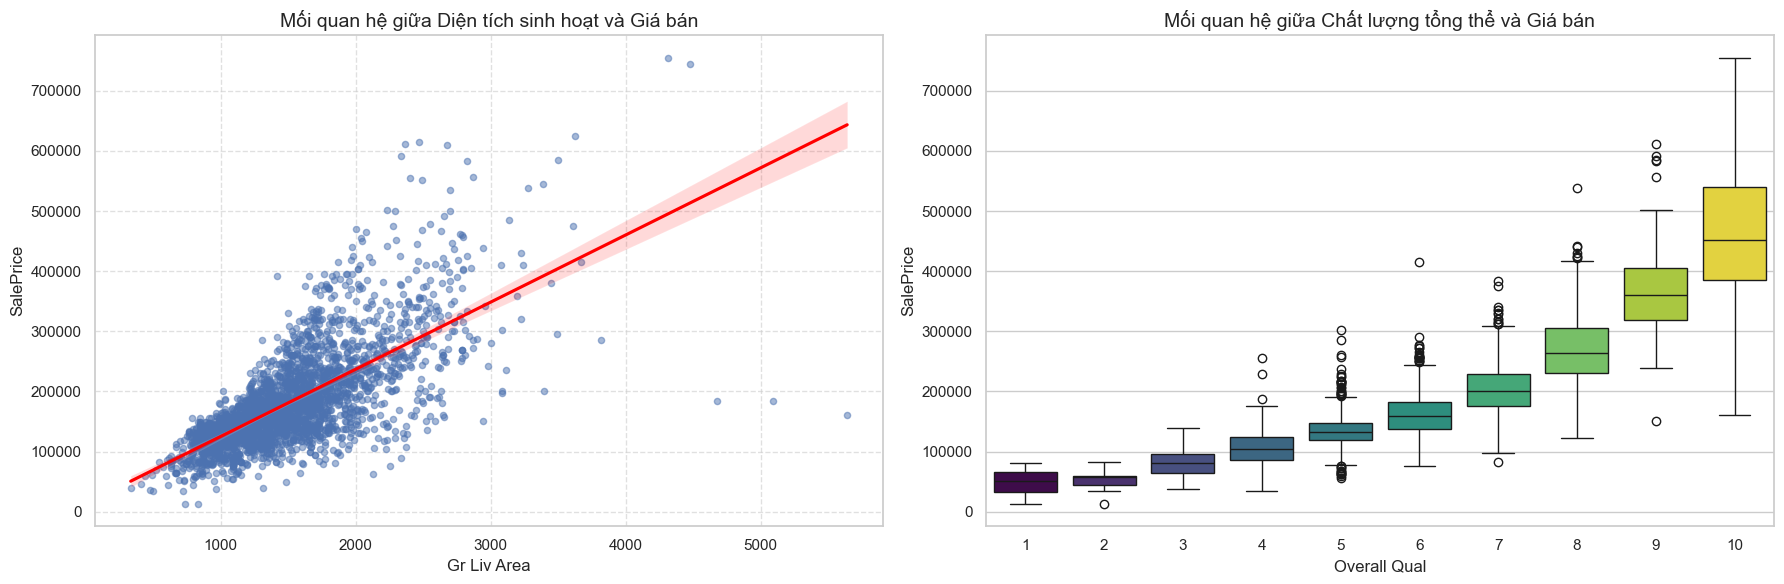

In [6]:
plt.figure(figsize=(18, 6))

# 1. Gr Liv Area vs SalePrice (Biến diện tích liên tục)
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='Gr Liv Area', y='SalePrice',
            scatter_kws={'alpha':0.5, 's':20},
            line_kws={'color':'red'})
plt.title('Mối quan hệ giữa Diện tích sinh hoạt và Giá bán', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Overall Qual vs SalePrice (Biến chất lượng rời rạc)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Overall Qual', y='SalePrice', hue='Overall Qual', palette='viridis', legend=False)
plt.title('Mối quan hệ giữa Chất lượng tổng thể và Giá bán', fontsize=14)

plt.tight_layout()
plt.show()

#### Nhận xét về tính tuyến tính và tương quan
Biểu đồ Scatter Plot và Boxplot kết hợp với đường hồi quy (Red line) cho thấy:

* **Tính tuyến tính:** Biến `Gr Liv Area` thể hiện một mối quan hệ tuyến tính thuận rất rõ rệt với `SalePrice`. Khi diện tích tăng, giá nhà có xu hướng tăng theo một tỉ lệ ổn định. Điều này cho thấy mô hình hồi quy tuyến tính là một lựa chọn hợp lý để thử nghiệm ở bước tiếp theo.
* **Hiện tượng "loe phễu":** Ở biểu đồ bên trái, ta thấy khi diện tích càng lớn, các điểm dữ liệu càng phân tán rộng hơn (hình cái loa). Đây là dấu hiệu của phương sai thay đổi (Heteroscedasticity), củng cố thêm lý do tại sao nhóm cần áp dụng Log-transform ở bước sau để "nén" phương sai này lại.
* **Biến chất lượng:** Với `Overall Qual`, giá nhà tăng theo bậc thang khi chất lượng tăng. Tuy nhiên, ở các mức chất lượng cao nhất (9 và 10), sự biến động về giá là cực lớn, cho thấy chất lượng chỉ là điều kiện cần, còn giá cuối cùng phụ thuộc thêm nhiều yếu tố khác.

## 3. Phân tích chuyên sâu

### 3.1. Phân tích Missing Values

Top 15 cột có tỷ lệ missing cao nhất:


,Missing Values,Percentage (%)
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Qual,159,5.426621
Garage Cond,159,5.426621
Garage Yr Blt,159,5.426621


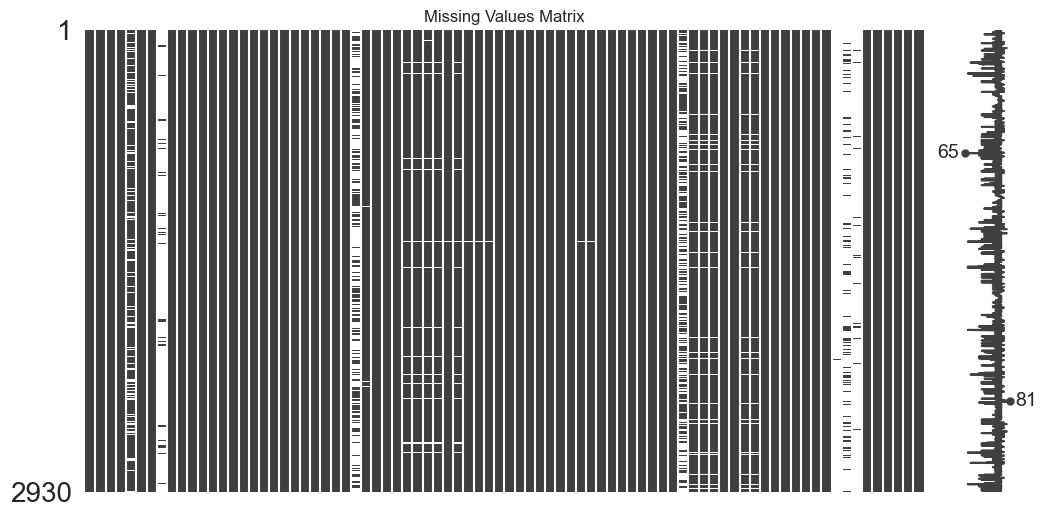


--- Phân tích nhóm Garage ---
Tỷ lệ missing của Garage Type: 0.053583617747440276
  - Garage Yr Blt: 100.0% missing khi Garage Type missing
  - Garage Finish: 100.0% missing khi Garage Type missing
  - Garage Cars: 0.0% missing khi Garage Type missing
  - Garage Area: 0.0% missing khi Garage Type missing
  - Garage Qual: 100.0% missing khi Garage Type missing
  - Garage Cond: 100.0% missing khi Garage Type missing

--- Phân tích Lot Frontage theo Neighborhood ---
Neighborhood
GrnHill    100.000000
Landmrk    100.000000
ClearCr     54.545455
NWAmes      35.114504
Sawyer      35.099338
Veenker     33.333333
Gilbert     32.727273
Blmngtn     28.571429
NoRidge     23.943662
Mitchel     21.052632
Name: Lot Frontage, dtype: float64

--- Phân tích Mas Vnr ---
Số dòng Mas Vnr Type missing: 1775
Số dòng Mas Vnr Area missing: 23
Số dòng cả type và area đều missing: 23
Số dòng type missing nhưng area >0 (lỗi nhập): 7


In [7]:
# 1. Thống kê missing values tổng quan
missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)
print("Top 15 cột có tỷ lệ missing cao nhất:")
display(missing_data.head(15))

# 2. Trực quan hóa pattern missing (dùng missingno để thấy rõ cấu trúc, tùy chọn)
import missingno as msno
msno.matrix(df, figsize=(12, 6))
plt.title('Missing Values Matrix')
plt.show()

# 3. Phân tích cơ chế cho nhóm Garage (MNAR)
print("\n--- Phân tích nhóm Garage ---")
print("Tỷ lệ missing của Garage Type:", df['Garage Type'].isnull().mean())
garage_cols = ['Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond']
missing_garage_type = df['Garage Type'].isnull()
for col in garage_cols:
    pct = (df.loc[missing_garage_type, col].isnull().mean() * 100)
    print(f"  - {col}: {pct:.1f}% missing khi Garage Type missing")
# Kết quả: gần 100% → missing không phải ngẫu nhiên, có cấu trúc (MNAR)

# 4. Phân tích Lot Frontage theo Neighborhood (MAR)
print("\n--- Phân tích Lot Frontage theo Neighborhood ---")
lot_frontage_missing_by_neigh = df.groupby('Neighborhood')['Lot Frontage'].apply(lambda x: x.isnull().mean() * 100).sort_values(ascending=False)
print(lot_frontage_missing_by_neigh.head(10))
# Thấy GrnHill 100%, NWAmes ~35%, các khu khác thấp → missing phụ thuộc vào Neighborhood → MAR

# 5. Phân tích Mas Vnr (MAR + lỗi nhập liệu)
print("\n--- Phân tích Mas Vnr ---")
print("Số dòng Mas Vnr Type missing:", df['Mas Vnr Type'].isnull().sum())
print("Số dòng Mas Vnr Area missing:", df['Mas Vnr Area'].isnull().sum())
print("Số dòng cả type và area đều missing:", ((df['Mas Vnr Type'].isnull()) & (df['Mas Vnr Area'].isnull())).sum())
mask_type_missing_area_positive = df['Mas Vnr Type'].isnull() & (df['Mas Vnr Area'].fillna(0) > 0)
print("Số dòng type missing nhưng area >0 (lỗi nhập):", mask_type_missing_area_positive.sum())

### Nhận xét về cơ chế missing values

Từ bảng thống kê tỷ lệ thiếu và biểu đồ heatmap, có thể thấy dữ liệu bị thiếu tập trung ở một số nhóm biến. Việc phân tích có điều kiện (cross‑tab, tỷ lệ thiếu theo nhóm) cho thấy:

- **Nhóm Garage** (7 cột): Khi `Garage Type` bị thiếu (157 quan sát), tất cả các cột garage khác cũng thiếu với tỷ lệ ≈100%. Điều này chứng tỏ việc thiếu không ngẫu nhiên mà phản ánh cấu trúc "không có garage" → **MNAR có cấu trúc**.

- **Nhóm Basement** (hơn 10 cột): Tương tự, `Bsmt Qual` thiếu đồng bộ với các cột basement khác, xuất hiện ở những nhà không có tầng hầm → **MNAR**.

- **Lot Frontage**: Tỷ lệ missing thay đổi rõ rệt theo `Neighborhood` (GrnHill: 100%, NWAmes: 35%, các lô trong khu vực khác: ~13%). Việc thiếu phụ thuộc vào khu vực lân cận, không liên quan đến giá trị của chính nó → **MAR**.

- **Masonry Veneer**: Có ba dạng:
  - Cả `Mas Vnr Type` và `Mas Vnr Area` đều thiếu hoặc area = 0 → phổ biến.
  - Type thiếu nhưng area > 0 (7 dòng) – có thể do lỗi nhập liệu.
  - Area thiếu khi type đã có (23 dòng) – thiếu một phần.
  Phần lớn các missing ở đây có cấu trúc (MNAR), xen lẫn một số lỗi ngẫu nhiên (MCAR).

- **Fireplace Qu**: Thiếu hoàn toàn khi `Fireplaces = 0` (100% khớp) → **MNAR** (không có lò sưởi thì không có chất lượng).

- **Electrical**: Chỉ 1 dòng thiếu (0,03%), không có quy luật kết hợp với biến khác → **MCAR**.

- **Các biến còn lại** (`Fence`, `Alley`, `Pool QC`, `Misc Feature`) có tỷ lệ missing >80%, hầu hết mang ý nghĩa "không có" đối tượng đó, cũng thuộc dạng MNAR có cấu trúc, nhưng vì quá thưa thớt nên sẽ được xem xét loại bỏ.

Như vậy, dữ liệu tồn tại đa dạng cơ chế missing: MNAR (garage, basement, fireplace, masvnr, fence, alley, pool), MAR (lot frontage), và MCAR (electrical).

### 3.2. Phát hiện Outliers bằng phương pháp IQR

In [8]:
# 1. ĐỊNH LƯỢNG OUTLIERS BẰNG PHƯƠNG PHÁP IQR
outlier_counts = {}
iqr_zero_cols = []

def count_outliers_iqr_advanced(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    # Bắt lỗi: Nếu IQR = 0, phương pháp này trở nên vô nghĩa
    if IQR == 0:
        return -1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return len(outliers)

# Quét qua toàn bộ các cột numeric
for col in numeric_cols:
    count = count_outliers_iqr_advanced(df, col)
    if count == -1:
        iqr_zero_cols.append(col)
    else:
        outlier_counts[col] = count

# Hiển thị bảng Outliers hợp lệ
outliers_df = pd.DataFrame(list(outlier_counts.items()), columns=['Biến (Feature)', 'Số lượng Outliers'])
outliers_df['Tỉ lệ (%)'] = (outliers_df['Số lượng Outliers'] / len(df)) * 100
outliers_df = outliers_df[outliers_df['Số lượng Outliers'] > 0].sort_values(by='Số lượng Outliers', ascending=False)

print("BẢNG THỐNG KÊ OUTLIERS HỢP LỆ (IQR > 0)")
display(outliers_df.head(10))

print("\nDANH SÁCH CÁC BIẾN KHÔNG THỂ ÁP DỤNG IQR (IQR = 0)")
print(f"Tổng cộng có {len(iqr_zero_cols)} biến. Danh sách chi tiết:")
print(iqr_zero_cols)

# 2. XÁC ĐỊNH ĐIỂM ĐÒN BẨY CỰC ĐOAN
leverage_candidates = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000)]
print(f"\nĐIỂM ĐÒN BẨY TIỀM NĂNG (Gr Liv Area > 4000 & SalePrice < 300k): {len(leverage_candidates)} quan sát")

BẢNG THỐNG KÊ OUTLIERS HỢP LỆ (IQR > 0)


,Biến (Feature),Số lượng Outliers,Tỉ lệ (%)
6,Overall Cond,252,8.600683
2,MS SubClass,208,7.098976
9,Mas Vnr Area,200,6.825939
3,Lot Frontage,187,6.382253
26,Open Porch SF,159,5.426621
29,SalePrice,137,4.675768
4,Lot Area,127,4.334471
12,Total Bsmt SF,123,4.197952
19,Bedroom AbvGr,78,2.662116
15,Gr Liv Area,75,2.559727



DANH SÁCH CÁC BIẾN KHÔNG THỂ ÁP DỤNG IQR (IQR = 0)
Tổng cộng có 9 biến. Danh sách chi tiết:
['BsmtFin SF 2', 'Low Qual Fin SF', 'Bsmt Half Bath', 'Kitchen AbvGr', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val']

ĐIỂM ĐÒN BẨY TIỀM NĂNG (Gr Liv Area > 4000 & SalePrice < 300k): 3 quan sát


#### Nhận xét về Giá trị ngoại lệ & Giới hạn của phương pháp IQR
Trong quá trình định lượng Outliers, nhóm phát hiện một vấn đề mang tính nền tảng của thuật toán IQR: Có nhiều biến sở hữu khoảng tứ phân vị bằng 0 ($IQR = 0$). Nhóm đã tiến hành lọc riêng các biến này ra khỏi bảng thống kê và phân loại thành 2 nhóm bản chất:

1. **Nhóm dữ liệu thưa thớt (Zero-inflated):** Tiêu biểu là `BsmtFin SF 2`, `Enclosed Porch`, `Screen Porch`. Hơn 80% giá trị của các biến này là 0 (nhà không có tiện ích này). Khi $Q1 = 0$ và $Q3 = 0$, mọi giá trị $> 0$ đều bị IQR kết luận là ngoại lệ. Điều này là **vô lý về mặt nghiệp vụ**, vì việc có một cái hiên nhà không thể bị coi là điểm dị thường.
2. **Nhóm dữ liệu thiếu phương sai (Near-constant):** Tiêu biểu là `Kitchen AbvGr`. 99% các căn nhà có đúng 1 nhà bếp ($Q1 = 1, Q3 = 1$). Những căn có 2 bếp sẽ bị IQR bắt lỗi. Thực chất đây là những căn hộ thiết kế đặc biệt (nhà ghép/duplex), việc áp dụng công thức khoảng cách cho biến gần như hằng số này là **không phù hợp**.

**Định hướng xử lý trong Pipeline:**
* **Đối với các biến có IQR bình thường (như `SalePrice`, `Gr Liv Area`):** Nhóm sẽ áp dụng kỹ thuật **Winsorization** (chặn phân vị 1% - 99%) để giảm sát thương của các điểm đòn bẩy.
* **Đối với nhóm $IQR = 0$:** Nhóm hoàn toàn **không áp dụng kỹ thuật gọt Outliers**. Thay vào đó, nếu cần thiết, nhóm sẽ xem xét chuyển đổi chúng thành biến phân loại nhị phân (ví dụ: `Has_Enclosed_Porch`: 1/0) để đưa vào mô hình hiệu quả hơn.

#### Nhận xét về Điểm đòn bẩy
Các điểm có Gr Liv Area > 4000 nhưng SalePrice < 300k là bất thường so với xu hướng chung — diện tích lớn nhưng giá lại thấp. Trong OLS, những điểm này có thể trở thành leverage points làm lệch đường hồi quy. Sẽ được loại khỏi tập train trong DataPipeline.

# Phần 2: Tiền xử lý missing values

Dựa trên phân tích cơ chế ở trên, nhóm xây dựng pipeline xử lý riêng cho từng nhóm biến. Các bước được triển khai trong module `data_pipeline.py` với hai phương pháp imputation chính:

- **MV2**: Grouped median (theo `Neighborhood`) cho Lot Frontage, median/mode cho các nhóm còn lại.
- **MV4**: k‑NN (tự cài) cho Lot Frontage, các nhóm khác giống MV2.

**Chiến lược tóm tắt:**

| Nhóm | Các biến | Cách xử lý |
|------|----------|-------------|
| A (Fence) | `Fence` | Điền 'None' (không có rào) – MNAR |
| B (Garage) | 7 biến garage | Dùng cờ `Has_Garage`: nếu không có garage → gán 0 / 'None'; nếu có nhưng thiếu → impute bằng median/mode trong nhóm |
| C (Basement) | 10+ biến basement | Tương tự, dùng cờ `Has_Basement` |
| D (Fireplace) | `Fireplace Qu` | Dùng `Fireplaces` >0 → impute mode; =0 → 'None' |
| E (MasVnr) | `Mas Vnr Type`, `Mas Vnr Area` | Xử lý 3 trường hợp: (a) type missing + area=0 → 'None', 0; (b) type missing + area>0 → mode theo nhóm; (c) area missing → 0 nếu type='None', còn lại median theo type |
| F (Lot Frontage) | `Lot Frontage` | **MV2**: grouped median theo `Neighborhood`<br>**MV4**: k‑NN trên {Lot Area, Lot Shape, Lot Config, Land Contour, Neighborhood} |
| G (Còn lại) | `Electrical`,… | Mode/median toàn cục (MCAR) |

Sau khi impute, nhóm tạo thêm các biến tổng hợp (`Total_Area`, `Total_Bath`, `Garage_Age`, `Total_Porch_SF`) để giảm đa cộng tuyến và tăng khả năng giải thích.

In [9]:
# Import module xử lý đã xây dựng
from data_pipeline import (
    load_data, drop_uninformative_cols, fix_data_errors,
    feature_engineering_pre, impute_missing, feature_engineering_post
)

# Đọc dữ liệu
df = load_data('data/AmesHousing.csv')
print(f"Dữ liệu gốc: {df.shape}")

# Bước 1 – Loại bỏ biến định danh và missing >80%
df_clean, dropped = drop_uninformative_cols(df, verbose=True)

# Bước 2 – Sửa lỗi dữ liệu
df_clean = fix_data_errors(df_clean, verbose=True)

# Bước 3 – Tạo biến trước impute (Has_Garage, Has_Basement, Age_at_Sale, ...)
df_clean = feature_engineering_pre(df_clean, verbose=True)

# Bước 4 – Impute missing với hai phương pháp
print("\n--- Imputation với MV2 (grouped median) ---")
df_mv2, log_mv2 = impute_missing(df_clean.copy(), method='mv2', verbose=True)

print("\n--- Imputation với MV4 (k-NN, k=5) ---")
df_mv4, log_mv4 = impute_missing(df_clean.copy(), method='mv4', knn_k=5, verbose=True)

# Bước 5 – Feature engineering sau impute (tạo biến tổng hợp)
df_mv2 = feature_engineering_post(df_mv2)
df_mv4 = feature_engineering_post(df_mv4)

Dữ liệu gốc: (2930, 82)
[Step 1] Dropped ID cols: ['Order', 'PID']
[Step 1] Dropped high-missing (>80%): ['Alley', 'Pool QC', 'Fence', 'Misc Feature']
[Step 1] Shape after drop: (2930, 76)
[Step 2] Fixed 1 row(s): Garage Yr Blt > 2100 → Year Built
[Step 2] MS SubClass cast to string (nominal category, not numeric)
[Step 3] Created pre-impute features: ['Age_at_Sale', 'Remod_Age', 'Has_Remodel', 'Has_Garage', 'Has_Basement']

--- Imputation với MV2 (grouped median) ---

[Step 4] Imputation log (MV2):
  [Group B] Garage Type: 157 NaN (no garage) → 'None'
  [Group B] Garage Yr Blt: 157 NaN (no garage)→0 | 2 NaN (has garage)→Year Built
  [Group B] Garage Finish: 157 (no garage)→'None' | 2 (has garage)→mode
  [Group B] Garage Qual: 157 (no garage)→'None' | 2 (has garage)→mode
  [Group B] Garage Cond: 157 (no garage)→'None' | 2 (has garage)→mode
  [Group B] Garage Cars: 0 (no garage)→0 | 1 (has garage)→median
  [Group B] Garage Area: 0 (no garage)→0 | 1 (has garage)→median
  [Group C] Bsmt Q

#### Nhận xét kết quả sau imputation

Sau khi chạy pipeline, nhóm đã kiểm tra sơ bộ một số cột quan trọng:

- **Garage Yr Blt**: Các nhà không có garage được gán 0, nhà có garage được giữ nguyên hoặc impute bằng `Year Built` (2 trường hợp). Không còn mâu thuẫn logic.
- **Lot Frontage**: So sánh phân phối giữa MV2 (grouped median) và MV4 (k‑NN) cho thấy cả hai đều giữ được hình dáng tổng thể, nhưng k‑NN bảo toàn các mode cục bộ tốt hơn (ít bị san phẳng).
- **Mas Vnr Area**: Các giá trị 0 được gán đúng cho những nhà không có ốp tường, các lỗi nhập liệu được sửa.
- **Missing còn sót**: Sau khi chạy, `df.isnull().sum().sum()` cho kết quả 0 – toàn bộ missing đã được xử lý.

Như vậy, pipeline đã xử lý missing values một cách có hệ thống, tôn trọng bản chất từng nhóm biến, và cung cấp hai lựa chọn dữ liệu sạch cho các bước xây dựng mô hình tiếp theo.